In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle

features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd

path_3b = Path("../events/MG3/dataframes/threeTag_picoAOD.h5")
path_4b = Path("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
path_signal = Path("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b = pd.read_hdf(path_3b)
df_bg4b = pd.read_hdf(path_4b)
df_signal = pd.read_hdf(path_signal)
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]
loaded_df = {path_3b: df_3b, path_4b: df_bg4b, path_signal: df_signal}

In [3]:
experiment_name = "CR_fvt_training_ensemble_max_smeared"
hparams_filter = {
    "dataset": lambda x: (
        x["n_3b"] == 100_0000, 
        x["ratio_4b"] == 0.5,
        x["signal_filename"] == "HH4b_picoAOD.h5",
    ), 
    "experiment_name": experiment_name
}
hashes, hparams = TrainingInfo.find(hparams_filter, return_hparams=True)
metadata = TrainingInfo.load_cached_metadata()
existing = []
for hp in hparams:
    ns = metadata[hp["signal_region"]["SR_stats_hashes"][0]]["smearing"]["noise_scale"]
    sr = hp["dataset"]["signal_ratio"]
    seed = hp["dataset"]["seed"]
    SR_size = hp["signal_region"]["4b_in_SR"]
    existing.append((ns, sr, seed, SR_size))

In [4]:
metadata = TrainingInfo.load_cached_metadata()
hashes, hparams = TrainingInfo.find({"experiment_name": "CR_fvt_training_ensemble_max_fvt"}, return_hparams=True)

In [5]:
print(np.unique([hp["signal_region"]["4b_in_SR"] for hp in hparams]))

[0.05 0.1  0.15 0.2 ]


In [6]:
df = pd.DataFrame(existing, columns=["noise_scale", "signal_ratio", "seed", "SR_size"])
df.sort_values(by=["noise_scale", "signal_ratio", "seed", "SR_size"], inplace=True)
df

,noise_scale,signal_ratio,seed,SR_size
1054,0.5,0.00,0,0.05
1042,0.5,0.00,0,0.10
1022,0.5,0.00,0,0.15
1012,0.5,0.00,0,0.20
1050,0.5,0.00,1,0.05
...,...,...,...,...
5366,3.0,0.02,48,0.20
5987,3.0,0.02,49,0.05
5942,3.0,0.02,49,0.10
5966,3.0,0.02,49,0.15


In [7]:
pull_dict = {}
for experiment_name in ["CR_fvt_training_ensemble_max_fvt", "CR_fvt_training_ensemble_max_smeared"]:
    pull_dict_a = pickle.load(open(f"./data/pulls/pull_by_hashes_sr_stats_{experiment_name}.pkl", "rb"))
    pull_dict.update(pull_dict_a)

In [8]:
for hash in pull_dict:
    hparams = metadata[hash]
    signal_ratio = hparams["dataset"]["signal_ratio"]
    SR_size = hparams["signal_region"]["4b_in_SR"]    
    sr_stats_hash = hparams["signal_region"]["SR_stats_hashes"][0]
    sr_stats_type = hparams["signal_region"]["stats_type"]
    if sr_stats_type == "fvt":
        noise_scale = np.inf
    else:
        noise_scale = metadata[sr_stats_hash]["smearing"]["noise_scale"]
    
    for v in pull_dict[hash]:
        binning_mode = v["binning_mode"]
        nbins = v["nbins"]
        hists = v["hists"]
        hist_3b_rw = hists["3b_rw"]
        hist_3b_rw_sq = hists["3b_rw_sq"]
        hist_4b = hists["4b"]
        hist_4b_sq = hists["4b_sq"]
        var_o1 = hists["var_o1"]
        var_o2 = hists["var_o2"]
        hist_3b_o1 = hists["3b_corrected_o1"]
        hist_3b_o2 = hists["3b_corrected_o2"]
        hist_signal = hists["signal"]
        hist_bg4b = hists["bg4b"]
        
        if binning_mode == "train":
            var_o0 = hist_4b_sq + hist_3b_rw_sq
        else:
            var_o0 = hist_4b_sq + hist_3b_rw_sq / nbins**2

        v["signal_ratio"] = signal_ratio
        v["SR_size"] = SR_size
        v["noise_scale"] = noise_scale
        v["pull_o0"] = (hist_4b - hist_3b_rw) / np.sqrt(var_o0)
        v["pull_o1"] = (hist_4b - hist_3b_o1) / np.sqrt(var_o1)
        v["pull_o2"] = (hist_4b - hist_3b_o2) / np.sqrt(var_o2)
        v["pull_signal"] = hist_signal / np.sqrt(var_o0)
        v["pull_bg4b"] = (hist_bg4b - hist_3b_rw) / np.sqrt(var_o0)

/tmp/user/3393/ipykernel_4088472/1868189610.py:35: RuntimeWarning: invalid value encountered in divide
  v["pull_o0"] = (hist_4b - hist_3b_rw) / np.sqrt(var_o0)
/tmp/user/3393/ipykernel_4088472/1868189610.py:36: RuntimeWarning: invalid value encountered in divide
  v["pull_o1"] = (hist_4b - hist_3b_o1) / np.sqrt(var_o1)
/tmp/user/3393/ipykernel_4088472/1868189610.py:37: RuntimeWarning: invalid value encountered in divide
  v["pull_o2"] = (hist_4b - hist_3b_o2) / np.sqrt(var_o2)
/tmp/user/3393/ipykernel_4088472/1868189610.py:38: RuntimeWarning: invalid value encountered in divide
  v["pull_signal"] = hist_signal / np.sqrt(var_o0)
/tmp/user/3393/ipykernel_4088472/1868189610.py:39: RuntimeWarning: invalid value encountered in divide
  v["pull_bg4b"] = (hist_bg4b - hist_3b_rw) / np.sqrt(var_o0)
/tmp/user/3393/ipykernel_4088472/1868189610.py:35: RuntimeWarning: divide by zero encountered in divide
  v["pull_o0"] = (hist_4b - hist_3b_rw) / np.sqrt(var_o0)
/tmp/user/3393/ipykernel_4088472/186

In [11]:
nbins_list = [16, 32, 64]
pull_dict_as_list = []
for d in pull_dict.values():
    pull_dict_as_list.extend(d)

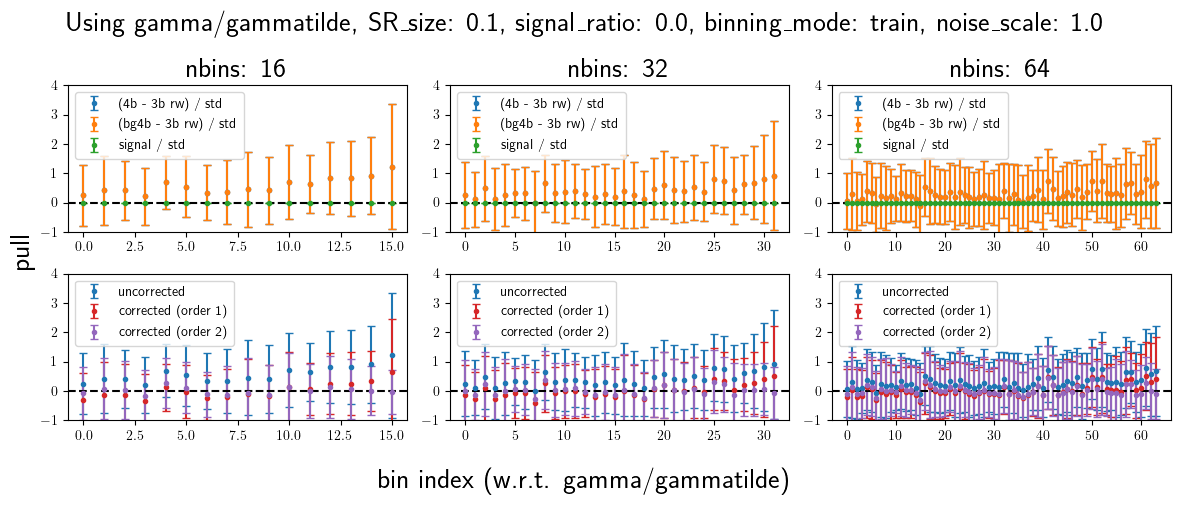

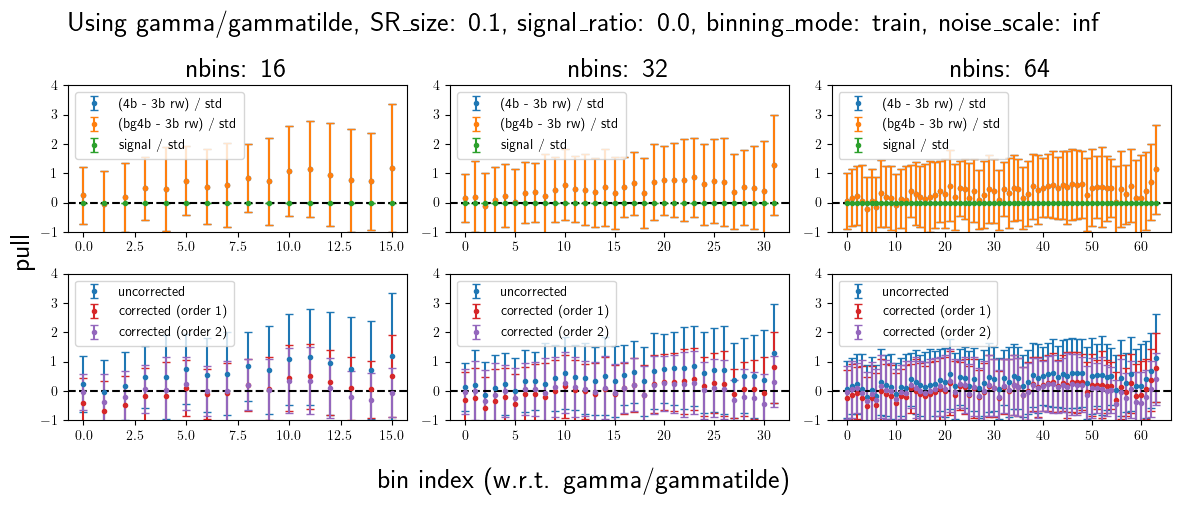

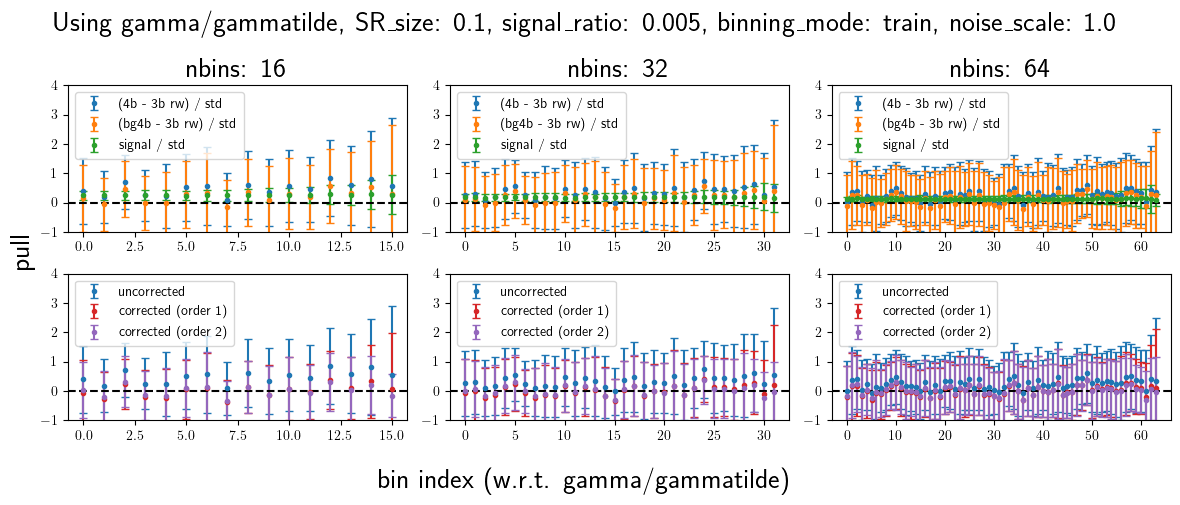

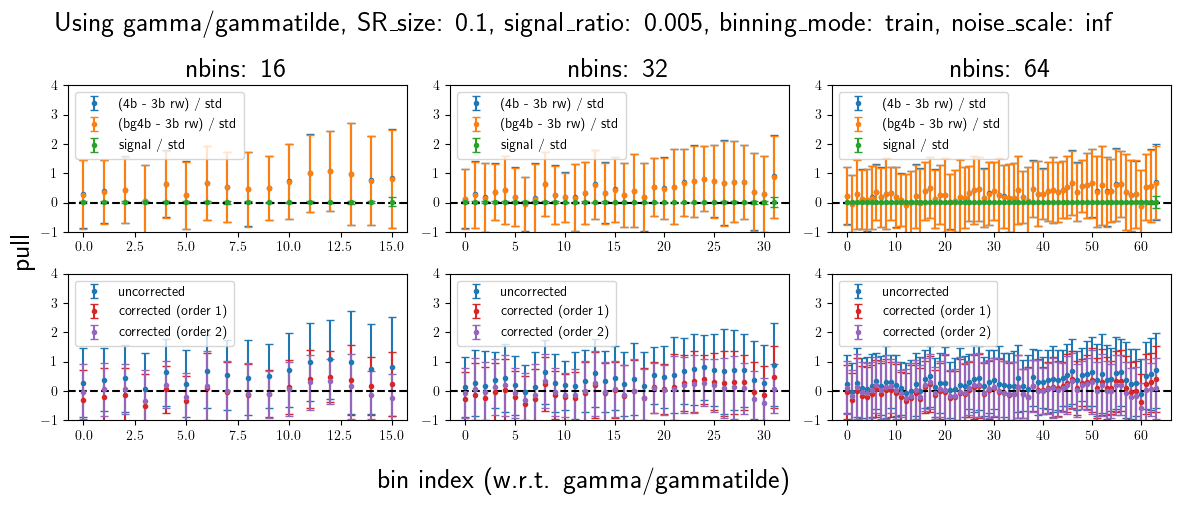

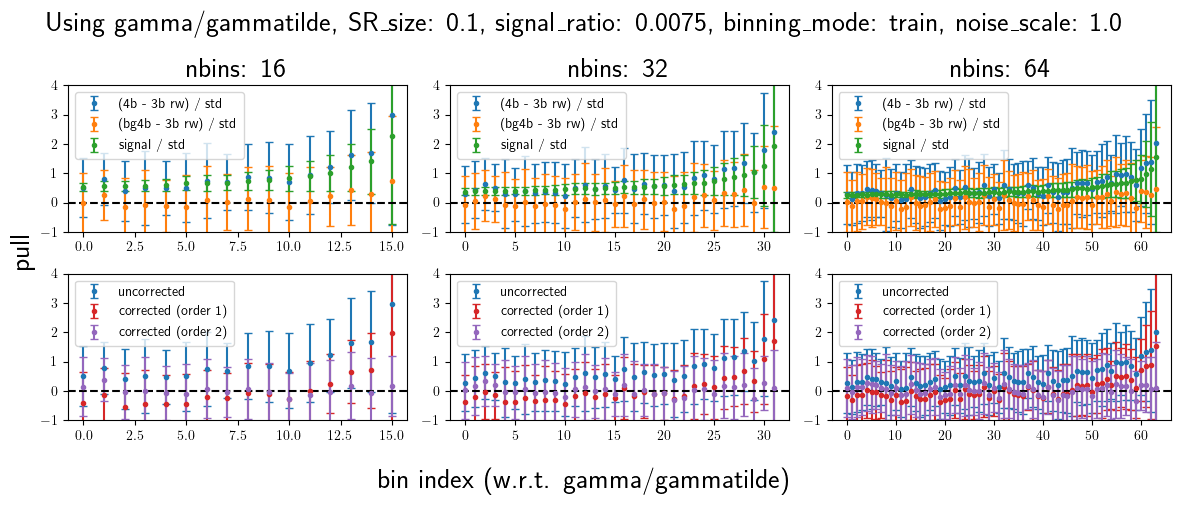

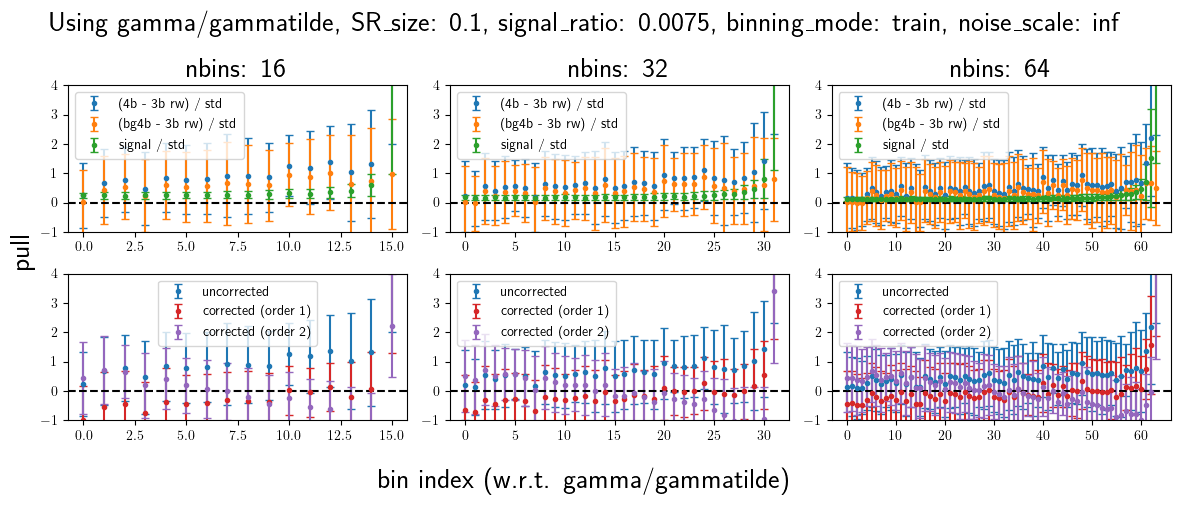

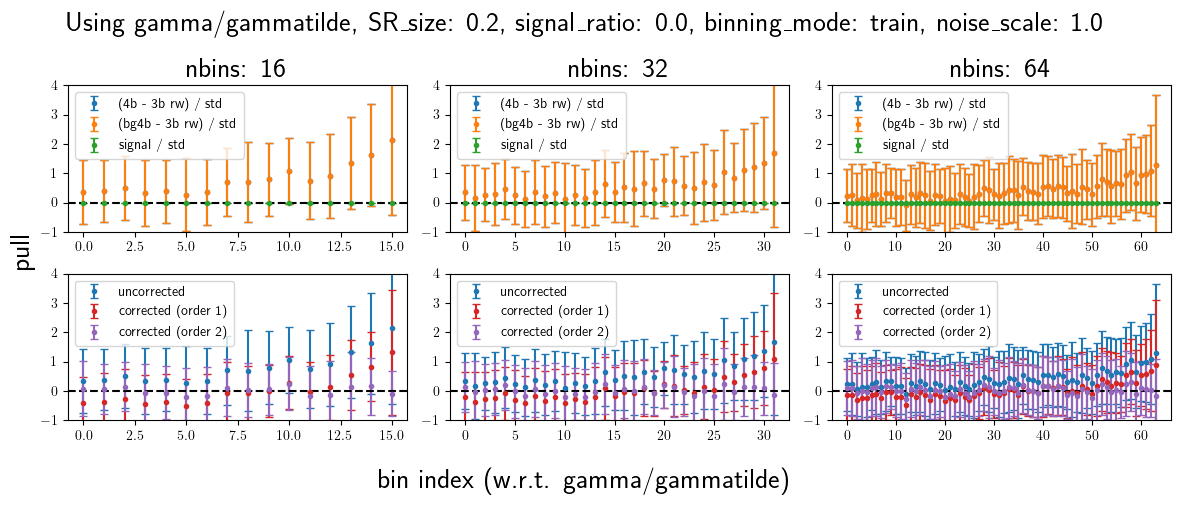

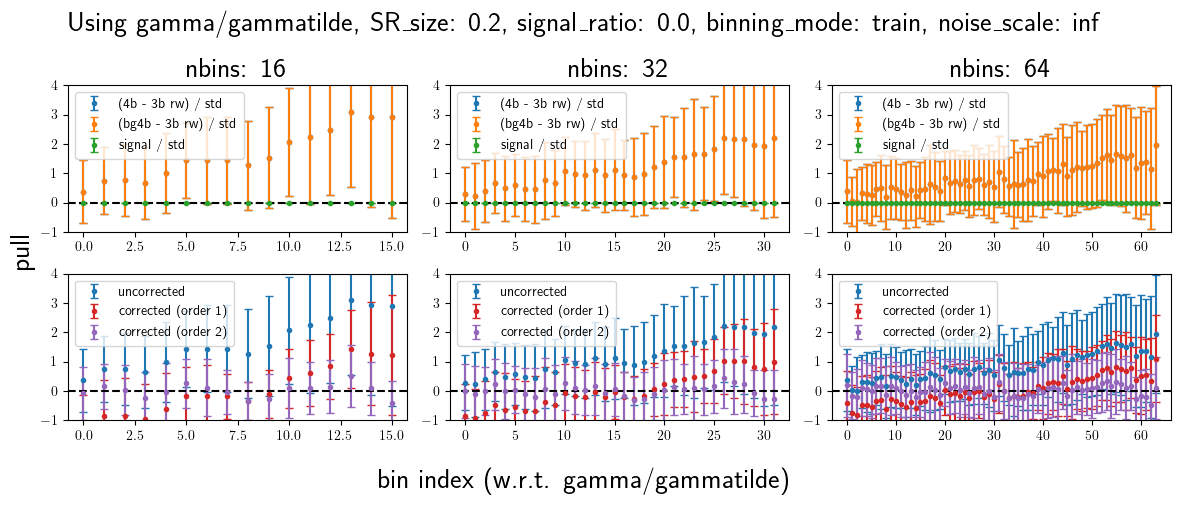

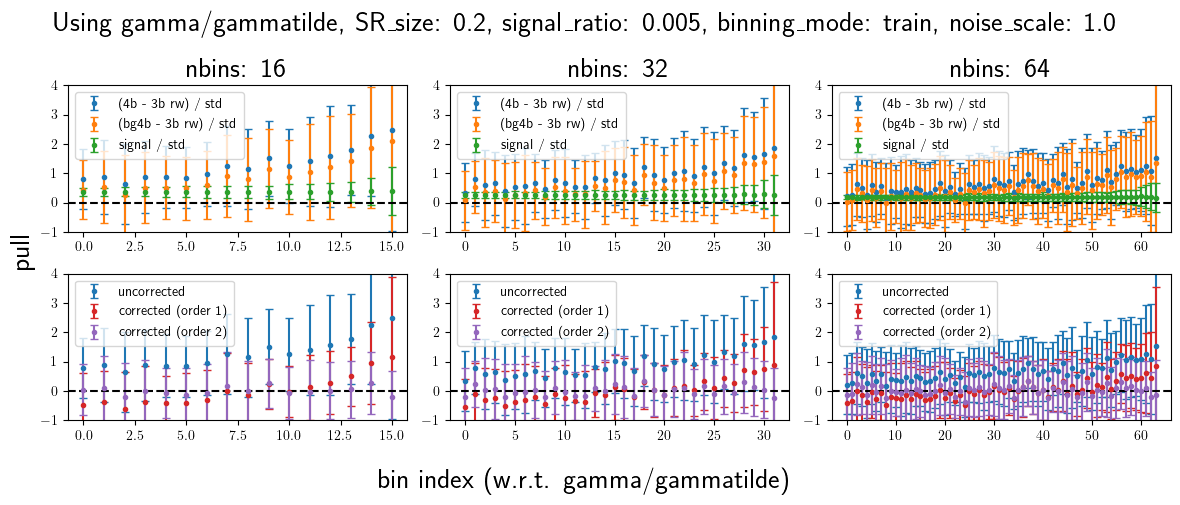

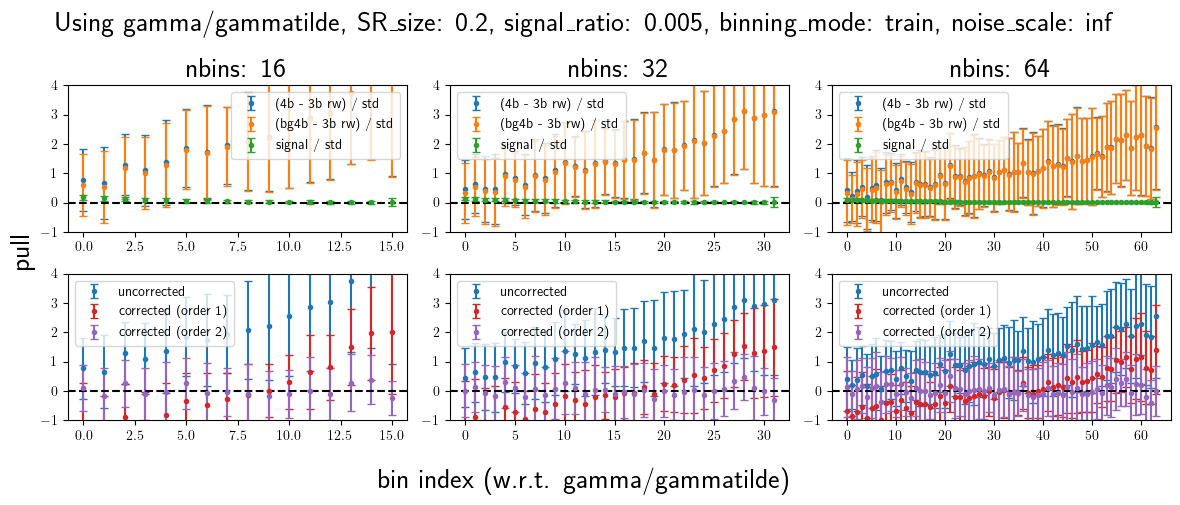

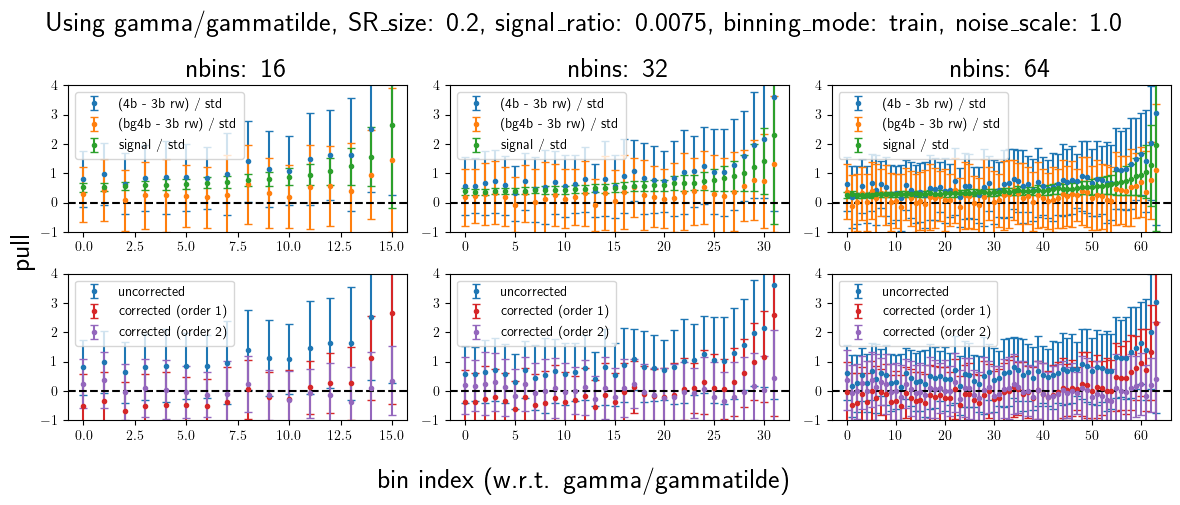

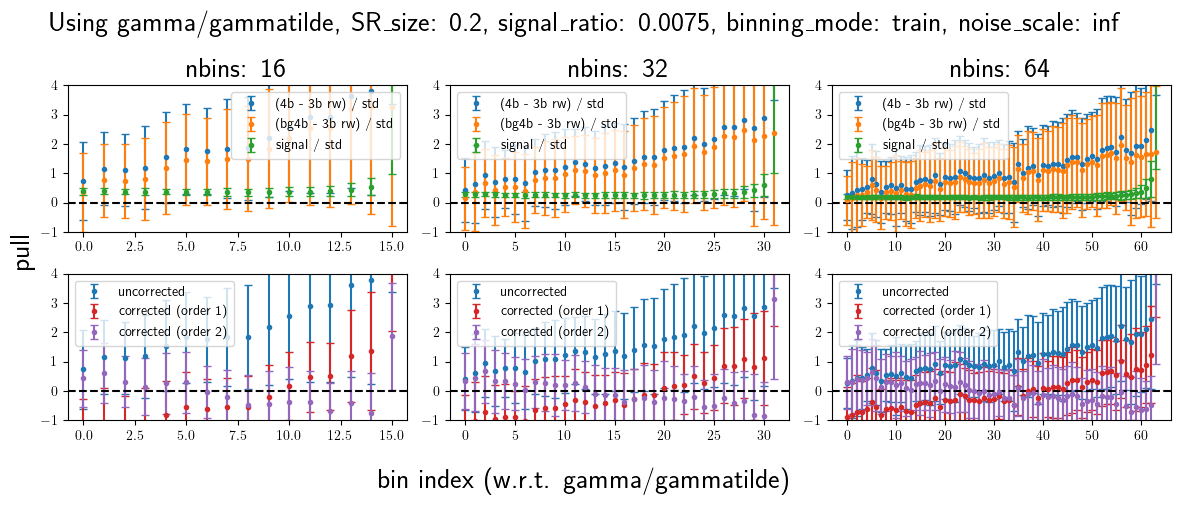

In [12]:
for SR_size in [0.1, 0.2]:
    for signal_ratio in [0.0, 0.005, 0.0075]:
        for binning_mode in ["train"]:
            for noise_scale in [1.0, np.inf]:
                fig, ax = plt.subplots(2, len(nbins_list), figsize=(len(nbins_list) * 4, 5))
                fig.suptitle(f"Using gamma/gammatilde, SR_size: {SR_size}, signal_ratio: {signal_ratio}, binning_mode: {binning_mode}, noise_scale: {noise_scale}")
                fig.supxlabel("bin index (w.r.t. gamma/gammatilde)")
                fig.supylabel("pull")
                tmp_dicts_target = [d for d in pull_dict_as_list if d["SR_size"] == SR_size 
                            and d["signal_ratio"] == signal_ratio
                            and d["binning_mode"] == binning_mode
                            and d["noise_scale"] == noise_scale]
                
                for nbins, ax_idx in zip(nbins_list, range(len(nbins_list))):
                    tmp_dicts = [d for d in tmp_dicts_target if d["nbins"] == nbins]
                    
                    pull_signal_mean = np.mean([d["pull_signal"] for d in tmp_dicts], axis=0)
                    pull_signal_std = np.std([d["pull_signal"] for d in tmp_dicts], axis=0)
                    
                    pull_bg4b_mean = np.mean([d["pull_bg4b"] for d in tmp_dicts], axis=0)
                    pull_bg4b_std = np.std([d["pull_bg4b"] for d in tmp_dicts], axis=0)
                    
                    pull_mean = np.mean([d["pull_o0"] for d in tmp_dicts], axis=0)
                    pull_std = np.std([d["pull_o0"] for d in tmp_dicts], axis=0)
                    
                    pull_mean_corrected_1 = np.mean([d["pull_o1"] for d in tmp_dicts], axis=0)
                    pull_std_corrected_1 = np.std([d["pull_o1"] for d in tmp_dicts], axis=0)
                    
                    pull_mean_corrected_2 = np.mean([d["pull_o2"] for d in tmp_dicts], axis=0)
                    pull_std_corrected_2 = np.std([d["pull_o2"] for d in tmp_dicts], axis=0)
                    
                    
                    current_ax_0 = ax[0, ax_idx]
                    current_ax_0.set_title(f"nbins: {nbins}")
                    bins = np.arange(nbins)
                    current_ax_0.errorbar(bins, pull_mean, yerr=pull_std, label="(4b - 3b rw) / std", capsize=3, fmt="o")
                    current_ax_0.errorbar(bins, pull_bg4b_mean, yerr=pull_bg4b_std, label="(bg4b - 3b rw) / std", capsize=3, fmt="o", 
                                        color=plt.get_cmap("tab10").colors[1])
                    current_ax_0.errorbar(bins, pull_signal_mean, yerr=pull_signal_std, label="signal / std", capsize=3, fmt="o", 
                                        color=plt.get_cmap("tab10").colors[2])
                    current_ax_0.axhline(0, color="black", linestyle="--")
                    current_ax_0.legend()
                    current_ax_0.set_ylim(-1, 4)
                    
                    current_ax_1 = ax[1, ax_idx]
                    current_ax_1.errorbar(bins, pull_mean, yerr=pull_std, label="uncorrected", capsize=3, fmt="o", 
                                        color=plt.get_cmap("tab10").colors[0])
                    current_ax_1.errorbar(bins, pull_mean_corrected_1, yerr=pull_std_corrected_1, label="corrected (order 1)", capsize=3, fmt="o", 
                                        color=plt.get_cmap("tab10").colors[3])
                    current_ax_1.errorbar(bins, pull_mean_corrected_2, yerr=pull_std_corrected_2, label="corrected (order 2)", capsize=3, fmt="o", 
                                        color=plt.get_cmap("tab10").colors[4])
                    current_ax_1.axhline(0, color="black", linestyle="--")
                    current_ax_1.legend()
                    current_ax_1.set_ylim(-1, 4)
                    
                plt.tight_layout()
                plt.show()
                
            colors = plt.get_cmap("tab10").colors

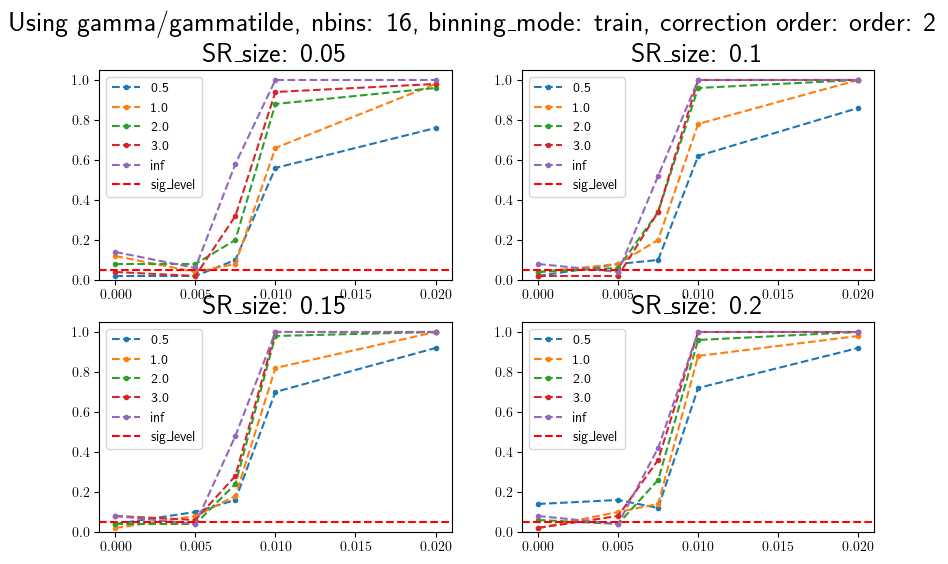

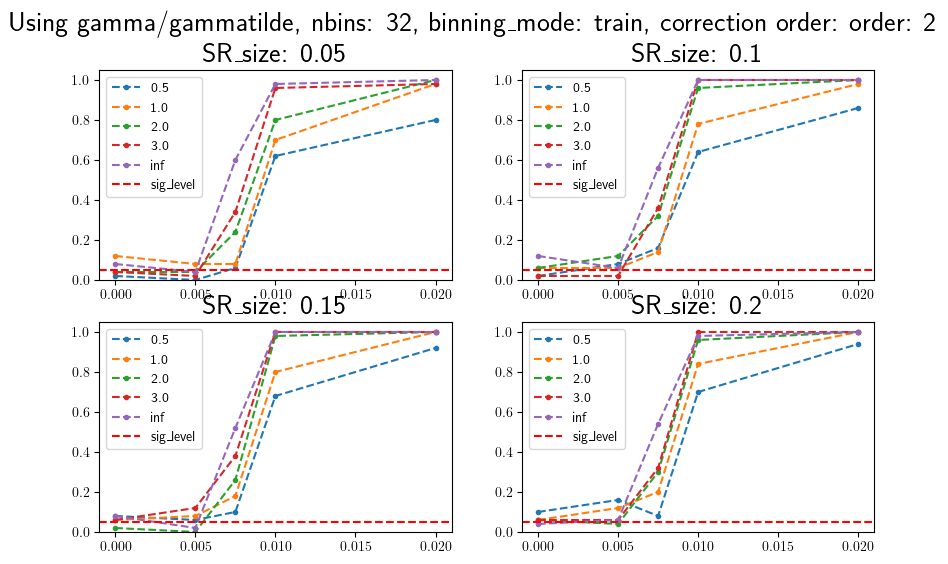

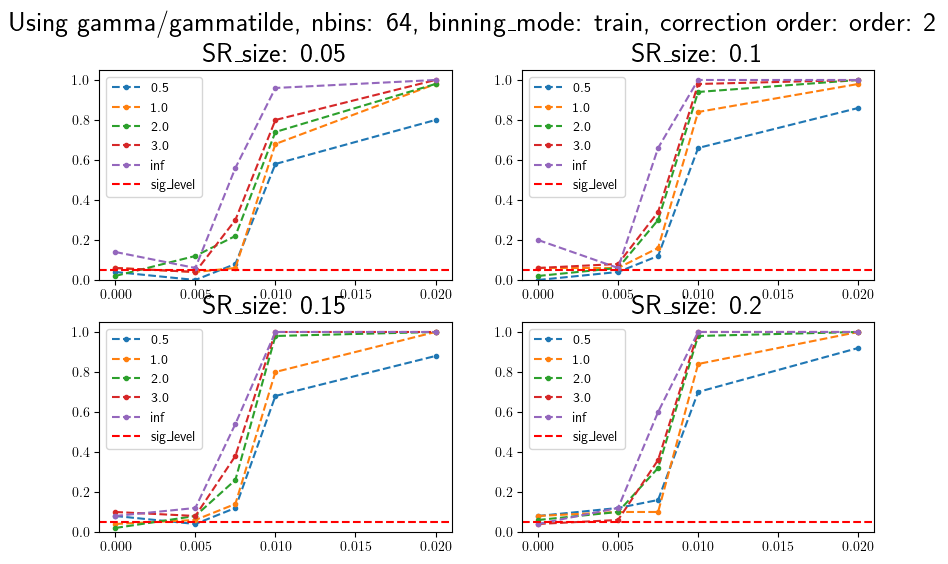

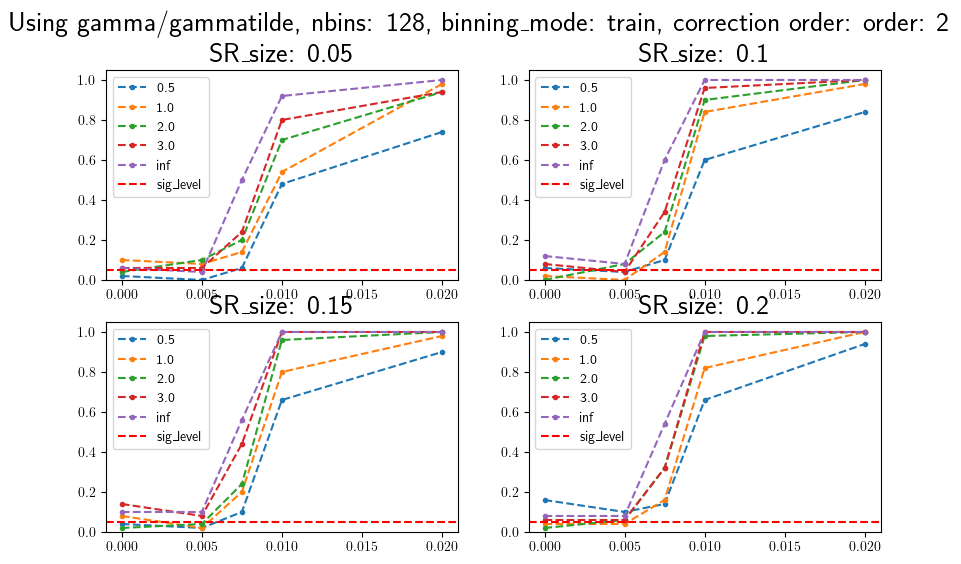

In [11]:
pull_df = pd.DataFrame([
    {"mean_pull_o0": np.sqrt(np.mean(v["pull_o0"]**2)), 
     "mean_pull_o1": np.sqrt(np.mean(v["pull_o1"]**2)), 
     "mean_pull_o2": np.sqrt(np.mean(v["pull_o2"]**2)), 
     "binning_mode": v["binning_mode"],
     "nbins": v["nbins"], 
     "SR_size": v["SR_size"], 
     "signal_ratio": v["signal_ratio"], 
     "noise_scale": v["noise_scale"]} for v in pull_dict_as_list])

from scipy.stats import chi2
sig_level = 0.05
pull_df["rej_o0"] = (chi2.ppf(1 - sig_level, df=pull_df["nbins"]) / pull_df["nbins"])**0.5
pull_df["rej_o1"] = (chi2.ppf(1 - sig_level, df=pull_df["nbins"] - 1) / pull_df["nbins"])**0.5
pull_df["rej_o2"] = (chi2.ppf(1 - sig_level, df=pull_df["nbins"] - 2) / pull_df["nbins"])**0.5
pull_df["rejected_o0"] = pull_df["mean_pull_o0"] > pull_df["rej_o0"]
pull_df["rejected_o1"] = pull_df["mean_pull_o1"] > pull_df["rej_o1"]
pull_df["rejected_o2"] = pull_df["mean_pull_o2"] > pull_df["rej_o2"]
pull_df_summary = pull_df.groupby(["SR_size", "signal_ratio", "nbins", "binning_mode", "noise_scale"]).mean().reset_index()


for nbins in [16, 32, 64, 128]:
    for binning_mode in ["train"]:
        # for noise_scale in [0.5, 1.0, 1.5, 2.0]:
        for correction_order, label in [
            # ("rejected_o0", "order: 0"), 
            #                     ("rejected_o1", "order: 1"), 
                                ("rejected_o2", "order: 2")
                                ]:
            fig, ax = plt.subplots(2, 2, figsize=(10, 6))
            fig.suptitle(f"Using gamma/gammatilde, nbins: {nbins}, binning_mode: {binning_mode}, correction order: {label}")
            colors = plt.get_cmap("tab10").colors
            for ax_idx, SR_size in enumerate([0.05, 0.1, 0.15, 0.2]):
                current_ax = ax[ax_idx // 2, ax_idx % 2]
                current_ax.set_title(f"SR_size: {SR_size}")

                for i, noise_scale in enumerate([0.5, 1.0, 2.0, 3.0, np.inf]):
                    pull_df_nbins = pull_df_summary[(pull_df_summary["SR_size"] == SR_size) 
                                                    & (pull_df_summary["nbins"] == nbins)
                                                    & (pull_df_summary["binning_mode"] == binning_mode)
                                                    & (pull_df_summary["noise_scale"] == noise_scale)
                                                    ]
                    current_ax.plot(pull_df_nbins["signal_ratio"], 
                                pull_df_nbins[correction_order], 
                                label=noise_scale, 
                                color=colors[i],
                                linestyle="--",
                                marker="o")
                    i += 1
                current_ax.axhline(y=sig_level, color="red", linestyle="--", label="sig_level")
                current_ax.set_ylim(0, 1.05)
                current_ax.legend()
            plt.show()